# Concept

```{contents}
```

In [1]:
%config InlineBackend.figure_format = 'svg'

import networkx as nx
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from rich.pretty import pprint

## Introduction

**[Graphs](<https://en.wikipedia.org/wiki/Graph_(abstract_data_type)>)** are one
of the most versatile and widely used data structures in computer science. A
graph is a collection of interconnected objects, where each object is capable of
maintaining an arbitrary number of connections to other objects. These objects
are typically referred to as
[**vertices**](<https://en.wikipedia.org/wiki/Vertex_(graph_theory)>) (or
nodes), and the connections between them are called
[**edges**](<https://en.wikipedia.org/wiki/Edge_(graph_theory)>) (or arcs).

Unlike arrays, which are linear and have a fixed size, graphs are **non-linear**
and can grow or shrink dynamically. This flexibility allows graphs to represent
complex relationships between different entities, making them suitable for a
wide range of applications.

In a graph, each vertex has a unique identifier, and each edge connects two
vertices. Depending on the nature of the connections, graphs can be classified
as either **[directed](https://en.wikipedia.org/wiki/Directed_graph)** or
**[undirected](<https://en.wikipedia.org/wiki/Graph_(discrete_mathematics)>)**.
In a directed graph, each edge has a direction, meaning it goes from one vertex
to another. In contrast, edges in an undirected graph have no direction, and
they simply connect two vertices.

Graphs are particularly useful for representing and solving problems that
involve relationships or interactions between entities. Some common use cases
for graphs include:

- **Social Networks**: Each user can be represented as a vertex, and
    friendships or connections between users can be represented as edges. Social
    networks like [Facebook](https://en.wikipedia.org/wiki/Facebook) and
    [Twitter](https://en.wikipedia.org/wiki/Twitter) are examples of this use
    case.

- **Web Pages**: Each web page can be a vertex, and hyperlinks between pages
    can be edges. This is the fundamental concept behind
    [Google's PageRank algorithm](https://en.wikipedia.org/wiki/PageRank).

- **Transport Networks**: Locations such as cities or intersections can be
    vertices, and roads or routes connecting these locations can be edges. This
    is the underlying principle behind navigation services like
    [Google Maps](https://en.wikipedia.org/wiki/Google_Maps).

- **Dependency Trees**: In software engineering, graphs can represent
    dependencies between different parts of a system. Each part is a vertex, and
    dependencies are edges. This is commonly used in build systems like
    [Make](<https://en.wikipedia.org/wiki/Make_(software)>) and package managers
    like [npm](<https://en.wikipedia.org/wiki/Npm_(software)>).

Despite their complexity, graphs offer a powerful way to model and solve complex
problems in computer science and many other fields. A deep understanding of how
they work is key to designing efficient algorithms and systems. For more details
about graphs, you can visit
[Wikipedia](<https://en.wikipedia.org/wiki/Graph_(abstract_data_type)>).

## Definition

```{prf:definition} Undirected Simple Graph
:label: undirected-graph-definition

An **Undirected Graph** is a specific type of mathematical structure that is
used extensively in the field of computer science and mathematics. It is defined
as an ordered pair $G=(V, E)$, where:

- $V$ represents a set of **vertices** (also referred to as nodes or points).
    Each vertex is a distinct entity within the graph.

- $E \subseteq \left\{\left\{x, y \right\} \mid x, y \in V \land x \neq y\right\}$
    is a set of **edges** (also known as links or lines). Each edge in this set
    is an unordered pair of vertices, denoted as $\{x, y\}$, where $x$ and $y$
    are distinct vertices from the set $V$ ($x, y \in V$ and $x \neq y$). This
    means that each edge connects two different vertices.

This definition pertains specifically to an
**[Undirected Simple Graph](<https://en.wikipedia.org/wiki/Graph_(discrete_mathematics)>)**.
In such a graph, each edge has no orientation, meaning it doesn't point from one
vertex to another but simply connects them.
```

```{prf:definition} Directed Simple Graph
:label: directed-graph-definition

A **Directed Graph** or **Digraph** is another common type of graph where edges
have orientations. In the strictest sense, a directed graph is an ordered pair
$G=(V, E)$, where:

- $V$ is a set of **vertices** (also referred to as nodes or points). Each
    vertex is a unique entity within the graph.

- $E \subseteq\left\{(x, y) \mid(x, y) \in V^2 \land x \neq y\right\}$ is a
    set of **edges** (also known as directed edges, directed links, directed
    lines, arrows, or arcs). Each edge in this set is an ordered pair of
    vertices, denoted as $(x, y)$, where $x$ and $y$ are distinct vertices from
    the set $V$ ($x, y \in V$ and $x \neq y$). This means that each edge points
    from one vertex to another.

This definition pertains specifically to a
**[Directed Simple Graph](https://en.wikipedia.org/wiki/Directed_graph)**. In
such a graph, each edge has a direction, indicating a one-way relationship
between two vertices.

In set theory and graph theory, $V^n$ denotes the set of $n$-tuples of elements
of $V$, that is, ordered sequences of $n$ elements that are not necessarily
distinct. Thus, $V^2$ is the set of all 2-tuples $(x, y)$ where $x$ and $y$ are
in $V$.
```

## Example
Let's consider a running example to understand these definitions better. Suppose
we have the below graph.

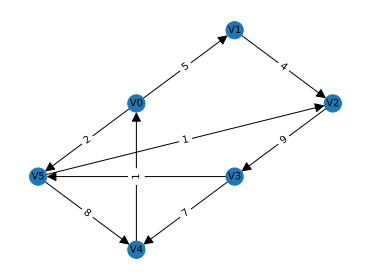

In [2]:
# Create a directed graph
G = nx.DiGraph()

# Add edges with weights
G.add_edge('V0', 'V1', weight=5)
G.add_edge('V1', 'V2', weight=4)
G.add_edge('V2', 'V3', weight=9)
G.add_edge('V3', 'V4', weight=7)
G.add_edge('V4', 'V0', weight=1)
G.add_edge('V0', 'V5', weight=2)
G.add_edge('V5', 'V4', weight=8)
G.add_edge('V3', 'V5', weight=3)
G.add_edge('V5', 'V2', weight=1)

# Manually specify positions
pos = {'V0': (0, 0), 'V1': (1, 1), 'V2': (2, 0), 'V3': (1, -1), 'V4': (0, -2), 'V5': (-1, -1)}

# nodes
nx.draw_networkx_nodes(G, pos, node_size=300)

# edges
nx.draw_networkx_edges(G, pos, width=1, arrowstyle='-|>', arrowsize=20)

# labels
nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif')

# edge labels
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.axis('off')
plt.show()


We will use this graph to illustrate the concepts discussed in this chapter.

## Common Notations

### Vertex

A **vertex** is a fundamental part of a
[graph](<https://en.wikipedia.org/wiki/Graph_(discrete_mathematics)>). It can
have a name, which we will call the "key". A vertex may also have additional
information, which we will call the "payload".

For example, in the graph represented above, the vertices are

$$
V = \left\{v_0, v_1, v_2, v_3, v_4, v_5\right\}.
$$

Each element in this set ($v_0, v_1, v_2, v_3, v_4, v_5$) is a vertex in the
graph.

### Edge

An **edge** is another fundamental part of a graph. An edge connects two
vertices to show that there is a relationship between them. Edges may be one-way
or two-way. If the edges in a graph are all one-way, we say that the graph is a
"[directed graph](https://en.wikipedia.org/wiki/Directed_graph)" or a "digraph".

In the above graph, the edges can be represented as:

$$
E = \left\{(v_0, v_1), (v_0, v_5), (v_1, v_2), (v_2, v_3), (v_3, v_4), (v_3, v_5), (v_4, v_0), (v_5, v_4), (v_5, v_2)\right\}.
$$

Here, each pair of vertices represents an edge in the graph. For example,
$(v_0, v_1)$ is an edge connecting vertex $v_0$ to vertex $v_1$.

### Weight

Edges may be [weighted](https://en.wikipedia.org/wiki/Weighted_graph) to show
that there is a cost to go from one vertex to another. For example, in a graph
of roads that connect one city to another, the weight on the edge might
represent the distance between the two cities.

In the graph above, we can add another element to the edge pair that indicates
the weight. For example, the edge between $v_0$ and $v_1$ has a weight of 5 and
can be written as $(v_0, v_1, 5)$. So, our set of edges is now:

$$
E = \left\{(v_0, v_1, 5), (v_0, v_5, 2), (v_1, v_2, 4), (v_2, v_3, 9), (v_3, v_4, 7), (v_3, v_5, 3), (v_4, v_0, 1), (v_5, v_4, 8), (v_5, v_2, 1)\right\}.
$$

### Path

A **path** in a graph is a sequence of vertices that are connected by edges.
Formally, we would define a path as $w_1, w_2, \ldots, w_n$ such that
$(w_i, w_{i+1}) \in E$ for all $1 \leq i \leq n-1$. The unweighted path length
is the number of edges in the path, specifically $n−1$. The weighted path length
is the sum of the weights of all the edges in the path.

For example, in our graph, the sequence $v_0 \to v_1 \to v_2$ is a path.

### Cycle

A **cycle** in a directed graph is a path that starts and ends at the same
vertex. A graph with no cycles is called an
[acyclic graph](https://en.wikipedia.org/wiki/Directed_acyclic_graph). A
directed graph with no cycles is called a **directed acyclic graph** or a
**DAG**.

In the graph represented above, the sequence
$v_0 \to v_1 \to v_2 \to v_3 \to v_4 \to v_0$ is a cycle. This is because it
starts and ends at the same vertex, $v_0$.

## Intuition

Consider the distinction between social networking platforms like Facebook and
Twitter to understand the differences between **undirected** and **directed**
graphs.

On **[Facebook](https://www.facebook.com/)**, when you send a friend request and
it's accepted, the friendship is mutual. You're friends with them, and they're
friends with you. This bilateral connection symbolizes an **undirected graph**,
as the relationship between two nodes (you and your friend) is symmetric,
meaning it goes both ways.

On the other hand, **[Twitter](https://twitter.com/)** operates differently. If
you follow someone on Twitter, that person isn't obligated to follow you back.
This creates a one-sided relationship, which is the premise of a **directed
graph**. In this type of graph, the relationship between two nodes (you and the
person you're following) isn't necessarily symmetric, meaning it might only go
one way.

Through these examples, we can understand how the concepts of directed and
undirected graphs apply in real-world scenarios.

## Edge List

An edge list is a straightforward and common way to represent a graph. In an
edge list, the graph is represented as a simple list of its edges. Each edge is
an ordered tuple of vertices. If the graph has weighted edges, each tuple also
includes the weight of the edge.

For a graph with vertices

$$
V = \{v_0, v_1, v_2, v_3, v_4, v_5\}
$$

and edges

$$
\begin{align*}
E = \{& \\
&(v_0, v_1, 5), \\
&(v_0, v_5, 2), \\
&(v_1, v_2, 4), \\
&(v_2, v_3, 9), \\
&(v_3, v_4, 7), \\
&(v_3, v_5, 3), \\
&(v_4, v_0, 1), \\
&(v_5, v_4, 8), \\
&(v_5, v_2, 1) \\
\}
\end{align*}
$$

The edge list representation would be:

$$
\begin{align*}
E' = [& \\
&(v_0, v_1, 5), \\
&(v_0, v_5, 2), \\
&(v_1, v_2, 4), \\
&(v_2, v_3, 9), \\
&(v_3, v_4, 7), \\
&(v_3, v_5, 3), \\
&(v_4, v_0, 1), \\
&(v_5, v_4, 8), \\
&(v_5, v_2, 1) \\
]
\end{align*}
$$

In this representation, each tuple signifies an edge from the first vertex to
the second vertex, with the corresponding weight. For example, $(v_0, v_1, 5)$
signifies an edge from $v_0$ to $v_1$ with weight $5$. Note that the edge list
representation does not include any information about the vertices in the graph.
This is because the vertices can be inferred from the edges.

So to recap, the edge list uses an array as the underlying structure, and each
element in the array is a tuple (or list) of vertices and weight. The size of
the array is the number of edges in the graph, denoted as $\|E\|$.

The figure below shows the edge list representation of the running example.

In [7]:
E = []

E.append(['v0', 'v1', 5])
E.append(['v0', 'v5', 2])
E.append(['v1', 'v2', 4])
E.append(['v2', 'v3', 9])
E.append(['v3', 'v4', 7])
E.append(['v3', 'v5', 3])
E.append(['v4', 'v0', 1])
E.append(['v4', 'v5', 8])
E.append(['v5', 'v2', 1])

pprint(E)

[
│   ['v0', 'v1', 5],
│   ['v0', 'v5', 2],
│   ['v1', 'v2', 4],
│   ['v2', 'v3', 9],
│   ['v3', 'v4', 7],
│   ['v3', 'v5', 3],
│   ['v4', 'v0', 1],
│   ['v4', 'v5', 8],
│   ['v5', 'v2', 1]
]

### Advantages

1. **Space-efficient:** An edge list representation uses space proportional to
   the number of edges $\|E\|$, rather than the square of the number of vertices
   $\|V\|$. This makes it more space-efficient for
   [sparse graphs](https://en.wikipedia.org/wiki/Sparse_graph) where the number
   of edges is much less than $\|V\|^2$. For example, if you have a graph of
   social network connections where each person is only connected to a small
   number of people, the edge list representation would be more space-efficient
   than an adjacency matrix.

2. **Simplicity:** The edge list representation is simple and straightforward.
   It consists of a list of tuples, with each tuple representing an edge and its
   vertices. Unlike the
   [adjacency matrix](https://en.wikipedia.org/wiki/Adjacency_matrix) which
   requires a two-dimensional matrix, or
   [adjacency list](https://en.wikipedia.org/wiki/Adjacency_list) that requires
   a dictionary of lists, the edge list does not require complex data
   structures.

3. **Convenient for certain algorithms:** Some graph algorithms such as
   [Kruskal's algorithm](https://en.wikipedia.org/wiki/Kruskal%27s_algorithm)
   for finding a minimum spanning tree work with edge lists directly. These
   algorithms typically require the ability to consider each edge individually
   and in isolation, a task for which the edge list representation is perfectly
   suited.

### Disadvantages

1. **Slow lookups:** In an edge list, checking whether a specific edge exists
   between two vertices can be slow. Unlike the adjacency matrix, where this
   operation is $\mathcal{O}(1)$, you need to traverse the list of edges which
   takes $\mathcal{O}(\|E\|)$ time. This could be significant if you have a
   graph with a high number of edges and need to perform this operation
   frequently.

2. **Inefficient for neighbor queries:** If you need to frequently find all
   nodes adjacent to a specific node, an edge list can be inefficient. You would
   need to iterate through all the edges, checking if the given node is part of
   each edge. In contrast, an adjacency list provides this information directly
   and efficiently.

3. **Inefficient edge insertions and deletions:** If you need to dynamically add
   or remove edges, the edge list representation can be inefficient. Inserting
   or deleting edges requires traversing the list to find the appropriate spot
   or edge, which takes $\mathcal{O}(\|E\|)$ time.

4. **Potentially more space-consuming for dense graphs:** For
   [dense graphs](https://en.wikipedia.org/wiki/Dense_graph), where the number
   of edges is close to $\|V\|^2$, an edge list may use more space than an
   adjacency matrix. For example, in a graph where each vertex is connected to
   every other vertex, the adjacency matrix would use less space as it stores
   this information compactly in a two-dimensional array.

### Summary

Similar to adjacency lists and adjacency matrices, the choice of whether to use
an edge list depends on the specifics of your use case and the characteristics
of the graph you're working with. Edge lists can be a good choice when you have
a sparse graph and your main operation involves iterating through all edges.

### Implementation

TODO.

## Adjacency Matrix

An **[adjacency matrix](https://en.wikipedia.org/wiki/Adjacency_matrix)**
represents a finite graph using a square matrix. This matrix contains entries
that reveal whether pairs of vertices in the graph are adjacent. For each pair
of vertices in the adjacency matrix, the matrix entry at the position $(i,j)$
indicates the presence or absence of an edge between vertices $i$ and $j$ with
either a $1$ or $0$.

In a simple graph without self-loops, the diagonal of the adjacency matrix
should contain only $0$s. For undirected graphs, the adjacency matrix exhibits
symmetry.

Let's elucidate this with the running directed graph example:

Consider a graph $G = (V, E)$, where:

- $V$ is the set of vertices defined as:

    $$
    V = \{v_0, v_1, v_2, v_3, v_4, v_5\}
    $$

- $E$ is the set of edges defined as:

    $$
    \begin{align*}
    E = \{&(v_0, v_1, 5), \\
    &(v_0, v_5, 2), \\
    &(v_1, v_2, 4), \\
    &(v_2, v_3, 9), \\
    &(v_3, v_4, 7), \\
    &(v_3, v_5, 3), \\
    &(v_4, v_0, 1), \\
    &(v_5, v_4, 8), \\
    &(v_5, v_2, 1)\}
    \end{align*}
    $$

The adjacency matrix $\boldsymbol{A}$ for graph $G$ is a $6\times6$ matrix,
given the graph has six vertices. In this matrix, $\boldsymbol{A}_{i,j}$
represents the weight of the edge from vertex $v_i$ to vertex $v_j$, if this
edge exists. If there's no edge between these vertices, $\boldsymbol{A}_{i,j}$
equals $0$.

The adjacency matrix for our graph becomes:

$$
\boldsymbol{A} = \begin{bmatrix}
0 & 5 & 0 & 0 & 0 & 2 \\
0 & 0 & 4 & 0 & 0 & 0 \\
0 & 0 & 0 & 9 & 0 & 0 \\
0 & 0 & 0 & 0 & 7 & 3 \\
1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 8 & 0 \\
\end{bmatrix}_{6 \times 6}
$$

In this matrix $\boldsymbol{A}$, the entry at the $i$th row and $j$th column
corresponds to the weight of the edge from vertex $v_i$ to vertex $v_j$. If an
edge doesn't exist, the corresponding weight is 0.

The adjacency matrix plays a crucial role in many graph algorithms in computer
science. For instance, it finds application in the
**[Floyd–Warshall algorithm](https://en.wikipedia.org/wiki/Floyd%E2%80%93Warshall_algorithm)**,
which determines the shortest paths in a weighted graph. Other uses include
calculating the number of walks in a graph and quickly verifying whether two
nodes are connected.

The figure below illustrates the adjacency matrix for our running example graph.

In [3]:
# Define your PrettyTable
A = PrettyTable()

# Add field names (column headers)
A.field_names = ["", "v0", "v1", "v2", "v3", "v4", "v5"]

# Add rows of data
A.add_row(["v0", 0, 5, 0, 0, 0, 2])
A.add_row(["v1", 0, 0, 4, 0, 0, 0])
A.add_row(["v2", 0, 0, 0, 9, 0, 0])
A.add_row(["v3", 0, 0, 0, 0, 7, 3])
A.add_row(["v4", 1, 0, 0, 0, 0, 0])
A.add_row(["v5", 0, 0, 1, 0, 8, 0])

# Print the table
pprint(A)

+----+----+----+----+----+----+----+
|    | v0 | v1 | v2 | v3 | v4 | v5 |
+----+----+----+----+----+----+----+
| v0 | 0  | 5  | 0  | 0  | 0  | 2  |
| v1 | 0  | 0  | 4  | 0  | 0  | 0  |
| v2 | 0  | 0  | 0  | 9  | 0  | 0  |
| v3 | 0  | 0  | 0  | 0  | 7  | 3  |
| v4 | 1  | 0  | 0  | 0  | 0  | 0  |
| v5 | 0  | 0  | 1  | 0  | 8  | 0  |
+----+----+----+----+----+----+----+

### Advantages

1. **Fast Edge Existence Check:** In an adjacency matrix, the existence of an
   edge between two vertices can be checked in $\mathcal{O}(1)$ time. This makes
   it particularly useful for algorithms that require frequent edge lookups.

2. **Quick Neighbor Queries:** Finding all nodes adjacent to a particular node
   can be done in $\mathcal{O}(\|V\|)$ time, where $\|V\|$ is the number of
   vertices in the graph.

3. **Convenient for Dense Graphs:** The adjacency matrix representation is
   space-efficient for dense graphs, where the number of edges is close to
   $\|V\|^2$. This is because the matrix uses space proportional to the square
   of the number of vertices, which in the case of dense graphs, is usually
   close to the number of edges.

### Disadvantages

1. **Space Inefficient for Sparse Graphs:** For sparse graphs, where the number
   of edges is much less than $\|V\|^2$, an adjacency matrix may use more space
   than necessary, making it less efficient than other representations like edge
   lists or adjacency lists.

2. **Slow Edge Insertions and Deletions:** Adding or removing edges in an
   adjacency matrix is relatively slow and inefficient. These operations can
   take up to $\mathcal{O}(\|V\|^2)$ time in the worst-case scenario, as a new
   matrix of size $\|V\|^2$ may need to be created.

3. **Inefficient for Iterating Over All Edges:** If you need to iterate over all
   edges, an adjacency matrix can be inefficient, as it would require iterating
   over $\|V\|^2$ entries to find $\|E\|$ edges. This is slower than both the
   edge list and adjacency list representations.

### Summary

The choice to use an adjacency matrix, like edge lists or adjacency lists,
largely depends on the specific requirements of your use case and the
characteristics of the graph you're working with. An adjacency matrix could be a
good choice if you're dealing with dense graphs, or if your operations mostly
involve checking the existence of edges or finding adjacent nodes.

### Implementation

TODO.

## Adjacency List

The adjacency list is another common and popular way to represent a graph. In an
adjacency list, each vertex of the graph is associated with the collection of
its neighboring vertices or edges. This representation can be a linked list,
array, or any other abstract data type that can represent a collection of items.
Let's illustrate this with our directed, weighted graph:

Consider a graph with vertices

$$
V = \{v_0, v_1, v_2, v_3, v_4, v_5\}
$$

and edges

$$
E = \{ (v_0, v_1, 5), (v_0, v_5, 2), (v_1, v_2, 4), (v_2, v_3, 9), (v_3, v_4, 7), (v_3, v_5, 3), (v_4, v_0, 1), (v_5, v_4, 8), (v_5, v_2, 1) \}
$$

An adjacency list representation of the graph would look like this:

```markdown
v0: (v1, 5), (v5, 2) v1: (v2, 4) v2: (v3, 9) v3: (v4, 7), (v5, 3) v4: (v0, 1)
v5: (v4, 8), (v2, 1)
```

Each row corresponds to a vertex and the list of tuples adjacent to that vertex.
Each tuple represents an edge, with the first element of the tuple being the
adjacent vertex and the second being the weight of the edge.

In code, An implementation suggested by Guido van Rossum uses a hash table to
associate each vertex in a graph with an array of adjacent vertices. In this
representation, a vertex may be represented by any hashable object. There is no
explicit representation of edges as objects. We can represent the graph above
using this implementation as follows:

```python
graph = {
    'v0': [('v1', 5), ('v5', 2)],
    'v1': [('v2', 4)],
    'v2': [('v3', 9)],
    'v3': [('v4', 7), ('v5', 3)],
    'v4': [('v0', 1)],
    'v5': [('v4', 8), ('v2', 1)]
}
```

In this representation, each vertex is associated with a list of tuples. Each
tuple contains an adjacent vertex and the weight of the edge connecting them.
For example, `'v0': [('v1', 5), ('v5', 2)]` means that there are edges from `v0`
to `v1` and `v5`, with weights 5 and 2, respectively.

This adjacency list representation offers efficient space usage for sparse
graphs (where the number of edges is much less than the number of vertices
squared) and allows for efficient traversal of the edges connected to a given
vertex. However, it can be less efficient than an adjacency matrix for checking
the existence of a specific edge, and does not allow for direct access to a
specific edge.

### Hash Map of Hash Map

The "hashmap of hashmaps" representation for adjacency lists in an interview
context is a more general form of the adjacency list representation for graphs.
This concept originated from the need to handle different types of graphs, such
as unweighted and weighted, directed and undirected, as well as the need to
perform more complex operations efficiently.

In this representation, each key in the outer hashmap represents a vertex in the
graph, and the value associated with it is another hashmap. In this inner
hashmap, each key represents an adjacent vertex, and the value represents the
weight of the edge between the two vertices.

Here's an example representation:

```python
graph = {
    'v0': {'v1': 5, 'v5': 2},
    'v1': {'v2': 4},
    'v2': {'v3': 9},
    'v3': {'v4': 7, 'v5': 3},
    'v4': {'v0': 1},
    'v5': {'v4': 8, 'v2': 1}
}
```

This representation allows for efficient checking of the existence of a specific
edge, as well as direct access to a specific edge's weight, both in
$\mathcal{O}(1)$ time complexity, given a good hash function.

The choice between these two forms of adjacency list representation - list of
tuples versus hashmap of hashmaps - often comes down to the specific
requirements of the problem at hand, including the type of graph you're working
with and the operations you need to perform on it. The hashmap of hashmaps
representation provides additional capabilities, but may consume more space and
require more complex code, so it's important to choose the appropriate
representation based on the context.

### Advantages

1. **Space-efficient for sparse graphs:** The adjacency list uses space
   proportional to the number of edges and vertices, or $\|E\| + \|V\|$. This
   makes it a more space-efficient representation than the adjacency matrix for
   sparse graphs where the number of edges is much less than $\|V\|^2$.

2. **Fast neighbor lookups:** The adjacency list is ideal for algorithms that
   need to quickly access all the neighbors of a vertex, as each vertex's
   neighbors can be directly accessed.

3. **Dynamic sizing:** Unlike adjacency matrices, which need to be re-sized when
   new vertices are added, adjacency lists can easily accommodate new vertices
   or edges, making them a better choice for dynamic graphs.

### Disadvantages

1. **Slower to check for specific edges:** Unlike an adjacency matrix, which can
   check if an edge exists in constant time, the adjacency list requires a
   search through the list of neighbors, which can take linear time in the worst
   case.

2. **More complex data structure:** The adjacency list is more complex than the
   adjacency matrix or edge list, as it requires a collection of lists (or other
   data structure). This could add complexity to your code and may require more
   computational resources.

3. **Inefficient for dense graphs:** For dense graphs, where the number of edges
   is close to $\|V\|^2$, an adjacency list may use more space than an adjacency
   matrix, as it needs to store all edges individually.

As with the other representations, the choice of whether to use an adjacency
list will depend on the characteristics of the graph and the specifics of your
use case. An adjacency list is a good choice when you need to quickly access all
neighbors of a vertex and your graph is relatively sparse.

### Implementation



In [4]:
import sys
from pathlib import Path
parent_dir = str(Path().resolve().parents[1])
print(parent_dir)
sys.path.append(parent_dir)

/Users/gaohn/gaohn/gaohn-dsa


The version below is a simplified version which is useful for interview.

In [5]:
from dataclasses import dataclass, field
from typing import Dict, Any

@dataclass
class Graph:
    nodes: Dict[Any, Dict] = field(default_factory=dict)
    edges: Dict[Any, Dict] = field(default_factory=dict)

    def add_node(self, node):
        if node not in self.nodes:
            self.nodes[node] = {}

    def add_edge(self, node1, node2, weight=1):
        self.add_node(node1)
        self.add_node(node2)
        if node1 not in self.edges:
            self.edges[node1] = {}
        if node2 not in self.edges:
            self.edges[node2] = {}
        self.edges[node1][node2] = weight
        self.edges[node2][node1] = weight

    def get_nodes(self):
        return self.nodes.keys()

    def get_edges(self):
        return self.edges

# Let's create a graph
graph = Graph()

# Add nodes to the graph
graph.add_node('v0')
graph.add_node('v1')
graph.add_node('v2')

# Add edges
graph.add_edge('v0', 'v1', 5)
graph.add_edge('v1', 'v2', 7)
graph.add_edge('v0', 'v2', 2)

# Print nodes and their connections
for node in graph.get_nodes():
    print(f'{node}:')
    for conn, weight in graph.get_edges()[node].items():
        print(f'  connected to: {conn} with weight {weight}')


v0:
  connected to: v1 with weight 5
  connected to: v2 with weight 2
v1:
  connected to: v0 with weight 5
  connected to: v2 with weight 7
v2:
  connected to: v1 with weight 7
  connected to: v0 with weight 2


## References and Further Readings

- https://runestone.academy/ns/books/published/pythonds/Graphs/toctree.html
- https://medium.com/basecs/a-gentle-introduction-to-graph-theory-77969829ead8
- https://medium.com/basecs/from-theory-to-practice-representing-graphs-cfd782c5be38
- https://medium.com/basecs/going-broad-in-a-graph-bfs-traversal-959bd1a09255